In [ ]:
# ============================================================
# 0. Setup — imports and one seed
# ============================================================
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import random
import sys
from pathlib import Path

import numpy as np
import csv
import torch
import matplotlib.pyplot as plt

_DEMO_DIR = Path.cwd()
sys.path.insert(0, str(_DEMO_DIR))

from HierarchicalSparseCoding import (
    Config,
    compute_effective_dictionaries,
    save_dictionary_grid,
    show_hsc_recon_examples_nlayer,
    sparsity_stats,
)
from train_hsc import (
    train_main,
    make_dataset_loaders,
    prepare_eval_batch,
    build_eval_inference_context,
    collect_validation_snapshot,
)

SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cpu"
DATASET = "mnist"
EPOCHS = 25
BATCH_SIZE = 256
LAYER_DIMS = [256, 64]
LAMBDAS = [0.05, 0.05]
BETAS = [1.0]

# Main-paper methods. Hybrid+MFISTA is an appendix ablation, so it is omitted here.
MODES = ["ista", "mfista", "lista", "hybrid"]
METHOD_STEPS = {
    "ista": {"infer_steps": 50, "lista_steps": 1},
    "mfista": {"infer_steps": 20, "lista_steps": 1},
    "lista": {"infer_steps": 50, "lista_steps": 1},
    "hybrid": {"infer_steps": 5, "lista_steps": 1},
}
HYBRID_PRETRAIN = 5

MODE_LABELS = {
    "ista": "ISTA",
    "mfista": "MFISTA",
    "lista": "LISTA",
    "hybrid": "Hybrid",
}
MODE_COLORS = {
    "ista": "#56B4E9",
    "mfista": "#E69F00",
    "lista": "#009E73",
    "hybrid": "#0072B2",
}
MODE_MARKERS = {"ista": "o", "mfista": "s", "lista": "^", "hybrid": "D"}

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "#FCFCFD",
    "axes.edgecolor": "#222222",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

print(f"Dataset: {DATASET}")
print(f"Seed: {SEED}")
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

---

# 1. Train the shared two-layer models

論文の main comparison と同じ 2 層構成 `[256, 64]` を使い、各手法を **seed=1 のみ**で学習します。論文のような seed 平均・エラーバーは出さず、notebook では 1 本の再現しやすい曲線として表示します。

In [ ]:
# ============================================================
# 1. Train main methods once
# ============================================================
results = {}

for mode in MODES:
    steps = METHOD_STEPS[mode]
    print(f"\n{'=' * 64}")
    print(f"Training {MODE_LABELS[mode]} (seed={SEED})")
    print(f"{'=' * 64}")

    cfg = Config(
        mode=mode,
        lista_variant="shared",
        layer_dims=LAYER_DIMS,
        lambdas=LAMBDAS,
        betas=BETAS,
        lr_D=1e-3,
        lr_E=1e-3,
        infer_steps=steps["infer_steps"],
        lista_steps=steps["lista_steps"],
        eta_scale=1.0,
        hybrid_pretrain_epochs=HYBRID_PRETRAIN if mode == "hybrid" else 0,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        dc_center=False,
        print_every=500,
        device=DEVICE,
    )
    artifacts = train_main(cfg, dataset_name=DATASET, seed=SEED)
    results[mode] = {
        "Ds": artifacts.Ds,
        "infer_module": artifacts.infer_module,
        "run_dir": artifacts.run_dir,
    }

print("\nTraining complete.")
for mode, result in results.items():
    print(f"{MODE_LABELS[mode]:>7}: {result['run_dir']}")

---

# 2. Epoch vs loss first

論文では付録 Fig. `fig:e1_convergence` に対応する確認です。notebook では最初のグラフとして置き、学習が比較可能な条件で進んでいるかを先に見ます。

In [ ]:
# ============================================================
# 2. Learning curves: epoch vs loss first
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)

for mode in MODES:
    epoch_path = results[mode]["run_dir"] / "epoch_metrics.csv"
    with epoch_path.open(newline="") as f:
        df = list(csv.DictReader(f))
    label = MODE_LABELS[mode]
    color = MODE_COLORS[mode]
    marker = MODE_MARKERS[mode]

    epochs = [float(row["epoch"]) for row in df]
    losses = [float(row["loss"]) for row in df]
    recs = [float(row["rec_x"]) for row in df]
    axes[0].plot(epochs, losses, color=color, marker=marker, linewidth=2, markersize=4, label=label)
    axes[1].plot(epochs, recs, color=color, marker=marker, linewidth=2, markersize=4, label=label)

axes[0].set_title("Validation Loss")
axes[0].set_ylabel("Full sparse energy")
axes[1].set_title("Validation Reconstruction")
axes[1].set_ylabel("Reconstruction error")
for ax in axes:
    ax.set_xlabel("Epoch")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(MODES), frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(f"Training Curves on MNIST (seed={SEED})", y=1.02)
plt.tight_layout()
plt.savefig(_DEMO_DIR / "demo_01_epoch_curves.png", dpi=180, bbox_inches="tight")
plt.show()

---

# 3. Quality and latency

Main Figs. `fig:pareto_main` と `fig:budget_latency_main` の single-seed 簡略版です。横軸の budget は手法ごとの既定推論ステップ数で、Hybrid は `K + T_ref` として表示しています。

In [ ]:
# ============================================================
# 3. Final quality and latency
# ============================================================
metrics = []

for mode in MODES:
    steps = METHOD_STEPS[mode]
    cfg = Config(
        mode=mode,
        layer_dims=LAYER_DIMS,
        lambdas=LAMBDAS,
        betas=BETAS,
        infer_steps=steps["infer_steps"],
        lista_steps=steps["lista_steps"],
        batch_size=BATCH_SIZE,
        device=DEVICE,
    )
    _, _, _, test_loader = make_dataset_loaders(DATASET, batch_size=BATCH_SIZE)
    row = collect_validation_snapshot(
        cfg=cfg,
        Ds=results[mode]["Ds"],
        infer_module=results[mode]["infer_module"],
        val_loader=test_loader,
        run_name=mode,
        epoch=EPOCHS,
        run_dir=Path("/tmp/demo_metrics"),
    )
    budget = steps["lista_steps"] + steps["infer_steps"] if mode == "hybrid" else steps["infer_steps"]
    if mode == "lista":
        budget = steps["lista_steps"]
    metrics.append({
        "mode": mode,
        "method": MODE_LABELS[mode],
        "budget": budget,
        "test_loss": row["loss"],
        "test_rec_x": row["rec_x"],
        "infer_time_ms": row["infer_time_ms"],
        "sparse": row["sparse"],
    })

for row in metrics:
    print(f"{row['method']:<8} budget={row['budget']:>3} loss={row['test_loss']:.4f} rec={row['test_rec_x']:.4f} latency={row['infer_time_ms']:.4f} ms/sample")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for mode in MODES:
    row = next(item for item in metrics if item["mode"] == mode)
    kwargs = dict(color=MODE_COLORS[mode], marker=MODE_MARKERS[mode], s=80, label=MODE_LABELS[mode])
    axes[0].scatter(row["budget"], row["test_loss"], **kwargs)
    axes[1].scatter(row["budget"], row["test_rec_x"], **kwargs)
    axes[2].scatter(row["budget"], row["infer_time_ms"], **kwargs)

for ax, title, ylabel in [
    (axes[0], "Quality vs Budget", "Test loss"),
    (axes[1], "Reconstruction vs Budget", "Test reconstruction"),
    (axes[2], "Latency vs Budget", "ms / sample"),
]:
    ax.set_title(title)
    ax.set_xlabel("Inference budget")
    ax.set_ylabel(ylabel)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(MODES), frameon=False, bbox_to_anchor=(0.5, -0.05))
fig.suptitle(f"Main Comparison, Single Seed (seed={SEED})", y=1.02)
plt.tight_layout()
plt.savefig(_DEMO_DIR / "demo_02_quality_latency.png", dpi=180, bbox_inches="tight")
plt.show()

---

# 4. Hybrid budget allocation

Main Fig. `fig:hybrid_budget_main` の小型版です。学習済み Hybrid モデルを固定し、LISTA stages `K` と refinement steps `T_ref` の配分だけを変えて評価します。

In [ ]:
# ============================================================
# 4. Hybrid budget allocation: vary K and refinement steps at evaluation
# ============================================================
hybrid_rows = []
K_VALUES = [1, 2, 4]
T_REF_VALUES = [0, 1, 3, 5, 7]
_, _, _, test_loader = make_dataset_loaders(DATASET, batch_size=BATCH_SIZE)

for K in K_VALUES:
    for T_ref in T_REF_VALUES:
        cfg = Config(
            mode="hybrid",
            layer_dims=LAYER_DIMS,
            lambdas=LAMBDAS,
            betas=BETAS,
            infer_steps=T_ref,
            lista_steps=K,
            batch_size=BATCH_SIZE,
            device=DEVICE,
        )
        row = collect_validation_snapshot(
            cfg=cfg,
            Ds=results["hybrid"]["Ds"],
            infer_module=results["hybrid"]["infer_module"],
            val_loader=test_loader,
            run_name=f"hybrid_K{K}_T{T_ref}",
            epoch=EPOCHS,
            run_dir=Path("/tmp/demo_hybrid_budget"),
        )
        hybrid_rows.append({
            "K": K,
            "T_ref": T_ref,
            "budget": K + T_ref,
            "test_loss": row["loss"],
            "test_rec_x": row["rec_x"],
            "infer_time_ms": row["infer_time_ms"],
        })

print("K  T_ref  budget  test_loss  test_rec_x  infer_time_ms")
for row in hybrid_rows:
    print(f"{row['K']:>1}  {row['T_ref']:>5}  {row['budget']:>6}  {row['test_loss']:.4f}     {row['test_rec_x']:.4f}      {row['infer_time_ms']:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharex=True)
for K in K_VALUES:
    sub = sorted([row for row in hybrid_rows if row["K"] == K], key=lambda row: row["T_ref"])
    t_refs = [row["T_ref"] for row in sub]
    axes[0].plot(t_refs, [row["test_loss"] for row in sub], marker="o", linewidth=2, label=f"K={K}")
    axes[1].plot(t_refs, [row["test_rec_x"] for row in sub], marker="o", linewidth=2, label=f"K={K}")
    axes[2].plot(t_refs, [row["infer_time_ms"] for row in sub], marker="o", linewidth=2, label=f"K={K}")

for ax, title, ylabel in [
    (axes[0], "Loss", "Test loss"),
    (axes[1], "Reconstruction", "Test reconstruction"),
    (axes[2], "Latency", "ms / sample"),
]:
    ax.set_title(title)
    ax.set_xlabel("Refinement steps T_ref")
    ax.set_ylabel(ylabel)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(K_VALUES), frameon=False, bbox_to_anchor=(0.5, -0.05))
fig.suptitle(f"Hybrid Budget Allocation on MNIST (seed={SEED})", y=1.02)
plt.tight_layout()
plt.savefig(_DEMO_DIR / "demo_03_hybrid_budget.png", dpi=180, bbox_inches="tight")
plt.show()

---

# 5. Depth scaling

Main Fig. `fig:depth_scaling_main` の MNIST / Hybrid / single-seed 簡略版です。深さごとに Hybrid を学習し直します。

In [19]:
# ============================================================
# 5. Depth scaling: Hybrid only
# ============================================================
DEPTHS = {1: [256], 2: [256, 64], 4: [256, 192, 128, 64]}
depth_rows = []
depth_results = {}

for n_layers, dims in DEPTHS.items():
    print(f"\nTraining Hybrid depth={n_layers}, dims={dims}")
    cfg = Config(
        mode="hybrid",
        lista_variant="shared",
        layer_dims=dims,
        lambdas=[0.05] * n_layers,
        betas=[1.0] * (n_layers - 1),
        lr_D=1e-3,
        lr_E=1e-3,
        infer_steps=5,
        lista_steps=1,
        eta_scale=1.0,
        hybrid_pretrain_epochs=HYBRID_PRETRAIN,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        dc_center=False,
        print_every=500,
        device=DEVICE,
    )
    artifacts = train_main(cfg, dataset_name=DATASET, seed=SEED)
    depth_results[n_layers] = artifacts

    eval_cfg = Config(
        mode="hybrid",
        layer_dims=dims,
        lambdas=[0.05] * n_layers,
        betas=[1.0] * (n_layers - 1),
        infer_steps=5,
        lista_steps=1,
        batch_size=BATCH_SIZE,
        device=DEVICE,
    )
    _, _, _, test_loader = make_dataset_loaders(DATASET, batch_size=BATCH_SIZE)
    row = collect_validation_snapshot(
        cfg=eval_cfg,
        Ds=artifacts.Ds,
        infer_module=artifacts.infer_module,
        val_loader=test_loader,
        run_name=f"hybrid_L{n_layers}",
        epoch=EPOCHS,
        run_dir=Path("/tmp/demo_depth"),
    )
    depth_rows.append({
        "layers": n_layers,
        "test_loss": row["loss"],
        "test_rec_x": row["rec_x"],
        "infer_time_ms": row["infer_time_ms"],
    })

depth_rows = sorted(depth_rows, key=lambda row: row["layers"])
print("layers  test_loss  test_rec_x  infer_time_ms")
for row in depth_rows:
    print(f"{row['layers']:>6}  {row['test_loss']:.4f}     {row['test_rec_x']:.4f}      {row['infer_time_ms']:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharex=True)
for ax, metric, title, ylabel in [
    (axes[0], "test_loss", "Loss", "Test loss"),
    (axes[1], "test_rec_x", "Reconstruction", "Test reconstruction"),
    (axes[2], "infer_time_ms", "Latency", "ms / sample"),
]:
    ax.plot([row["layers"] for row in depth_rows], [row[metric] for row in depth_rows], marker="D", linewidth=2, color=MODE_COLORS["hybrid"])
    ax.set_title(title)
    ax.set_xlabel("Number of layers")
    ax.set_ylabel(ylabel)
    ax.set_xticks([row["layers"] for row in depth_rows])

fig.suptitle(f"Depth Scaling, Hybrid on MNIST (seed={SEED})", y=1.02)
plt.tight_layout()
plt.savefig(_DEMO_DIR / "demo_04_depth_scaling.png", dpi=180, bbox_inches="tight")
plt.show()


Training Hybrid depth=1, dims=[256]
save_dir = data/raw_data/hsc_hybrid_shared_20260624_232310
mode          hybrid | phase          hybrid | ep 01 step 000000 | energy 33.4568 | rec_x 30.8424 | rec_h 0.0000 | sparse 2.6144 | a1: |.|_1 0.2042, active 0.8767
mode          hybrid | phase          hybrid | ep 03 step 000500 | energy 3.8731 | rec_x 1.1442 | rec_h 0.0000 | sparse 2.7289 | a1: |.|_1 0.2132, active 0.9536
mode          hybrid | phase          hybrid | ep 05 step 001000 | energy 3.5252 | rec_x 0.9129 | rec_h 0.0000 | sparse 2.6124 | a1: |.|_1 0.2041, active 0.9387
mode          hybrid | phase          hybrid | ep 08 step 001500 | energy 3.3247 | rec_x 0.8612 | rec_h 0.0000 | sparse 2.4636 | a1: |.|_1 0.1925, active 0.8811
mode          hybrid | phase          hybrid | ep 10 step 002000 | energy 3.2532 | rec_x 0.8672 | rec_h 0.0000 | sparse 2.3860 | a1: |.|_1 0.1864, active 0.8270
mode          hybrid | phase          hybrid | ep 12 step 002500 | energy 3.1414 | rec_x 0.8791 |

KeyboardInterrupt: 

---

# 6. Sparsity by layer

論文の sparsity sweep は `lambda` を変えますが、ここでは 1 seed デモとして、既定 `lambda=0.05` の下で手法ごとのコードの疎性を確認します。

In [ ]:
# ============================================================
# 6. Sparsity by layer and method
# ============================================================
_, _, _, test_loader = make_dataset_loaders(DATASET, batch_size=BATCH_SIZE)
test_images, _ = next(iter(test_loader))
x = prepare_eval_batch(Config(device=DEVICE), test_images)

sparsity_rows = []
for mode in MODES:
    steps = METHOD_STEPS[mode]
    cfg = Config(
        mode=mode,
        layer_dims=LAYER_DIMS,
        lambdas=LAMBDAS,
        betas=BETAS,
        infer_steps=steps["infer_steps"],
        lista_steps=steps["lista_steps"],
        batch_size=BATCH_SIZE,
        device=DEVICE,
    )
    Ds_for_inf, lambdas, betas, etas = build_eval_inference_context(cfg, [d.detach() for d in results[mode]["Ds"]])
    codes = results[mode]["infer_module"](
        x=x,
        Ds_for_inference=Ds_for_inf,
        lambdas=lambdas,
        betas=betas,
        infer_steps=steps["infer_steps"],
        eta_scale=1.0,
        etas=etas,
    )
    for layer_idx, code_tensor in enumerate(codes, start=1):
        stats = sparsity_stats(code_tensor)
        sparsity_rows.append({
            "method": MODE_LABELS[mode],
            "mode": mode,
            "layer": layer_idx,
            "l1_mean": stats["l1_mean"],
            "active_frac": stats["active_frac"],
        })

print("method   layer  l1_mean  active_frac")
for row in sparsity_rows:
    print(f"{row['method']:<8} {row['layer']:>5}  {row['l1_mean']:.4f}   {row['active_frac']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharex=True)
for mode in MODES:
    sub = sorted([row for row in sparsity_rows if row["mode"] == mode], key=lambda row: row["layer"])
    layers = [row["layer"] for row in sub]
    axes[0].plot(layers, [row["l1_mean"] for row in sub], marker=MODE_MARKERS[mode], color=MODE_COLORS[mode], linewidth=2, label=MODE_LABELS[mode])
    axes[1].plot(layers, [row["active_frac"] for row in sub], marker=MODE_MARKERS[mode], color=MODE_COLORS[mode], linewidth=2, label=MODE_LABELS[mode])

axes[0].set_title("L1 mean")
axes[0].set_ylabel("Mean absolute activation")
axes[1].set_title("Active fraction")
axes[1].set_ylabel("Fraction nonzero")
for ax in axes:
    ax.set_xlabel("Layer")
    ax.set_xticks([1, 2])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=len(MODES), frameon=False, bbox_to_anchor=(0.5, -0.05))
fig.suptitle(f"Sparsity by Layer (seed={SEED})", y=1.02)
plt.tight_layout()
plt.savefig(_DEMO_DIR / "demo_05_sparsity.png", dpi=180, bbox_inches="tight")
plt.show()

---

# 7. Learned dictionaries and reconstructions

最後に定性的な確認として、学習された辞書原子と再構成例を表示します。

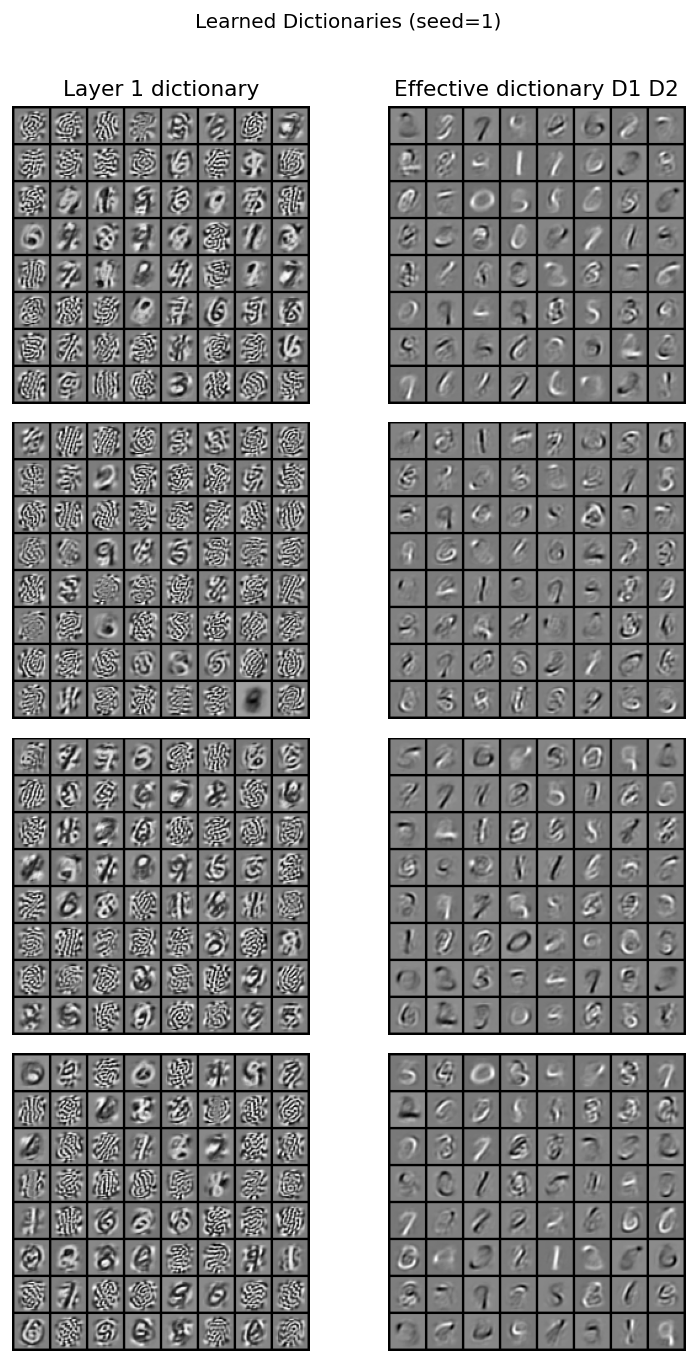

In [17]:
# ============================================================
# 7a. Learned dictionaries
# ============================================================
H, W = 28, 28
fig, axes = plt.subplots(len(MODES), 2, figsize=(7, 2.8 * len(MODES)))

for row_idx, mode in enumerate(MODES):
    Ds = results[mode]["Ds"]
    eff_dicts = compute_effective_dictionaries([d.detach() for d in Ds])

    d1_path = Path("/tmp") / f"demo_dict_l1_{mode}.png"
    eff_path = Path("/tmp") / f"demo_dict_eff_{mode}.png"
    save_dictionary_grid(Ds[0], H, W, str(d1_path), n_show=64)
    save_dictionary_grid(eff_dicts[1], H, W, str(eff_path), n_show=64)

    axes[row_idx, 0].imshow(plt.imread(d1_path))
    axes[row_idx, 0].axis("off")
    axes[row_idx, 0].set_ylabel(MODE_LABELS[mode], rotation=0, labelpad=30, va="center")

    axes[row_idx, 1].imshow(plt.imread(eff_path))
    axes[row_idx, 1].axis("off")

axes[0, 0].set_title("Layer 1 dictionary")
axes[0, 1].set_title("Effective dictionary D1 D2")
fig.suptitle(f"Learned Dictionaries (seed={SEED})", y=1.01)
plt.tight_layout()
plt.savefig(_DEMO_DIR / "demo_06_dictionaries.png", dpi=180, bbox_inches="tight")
plt.show()

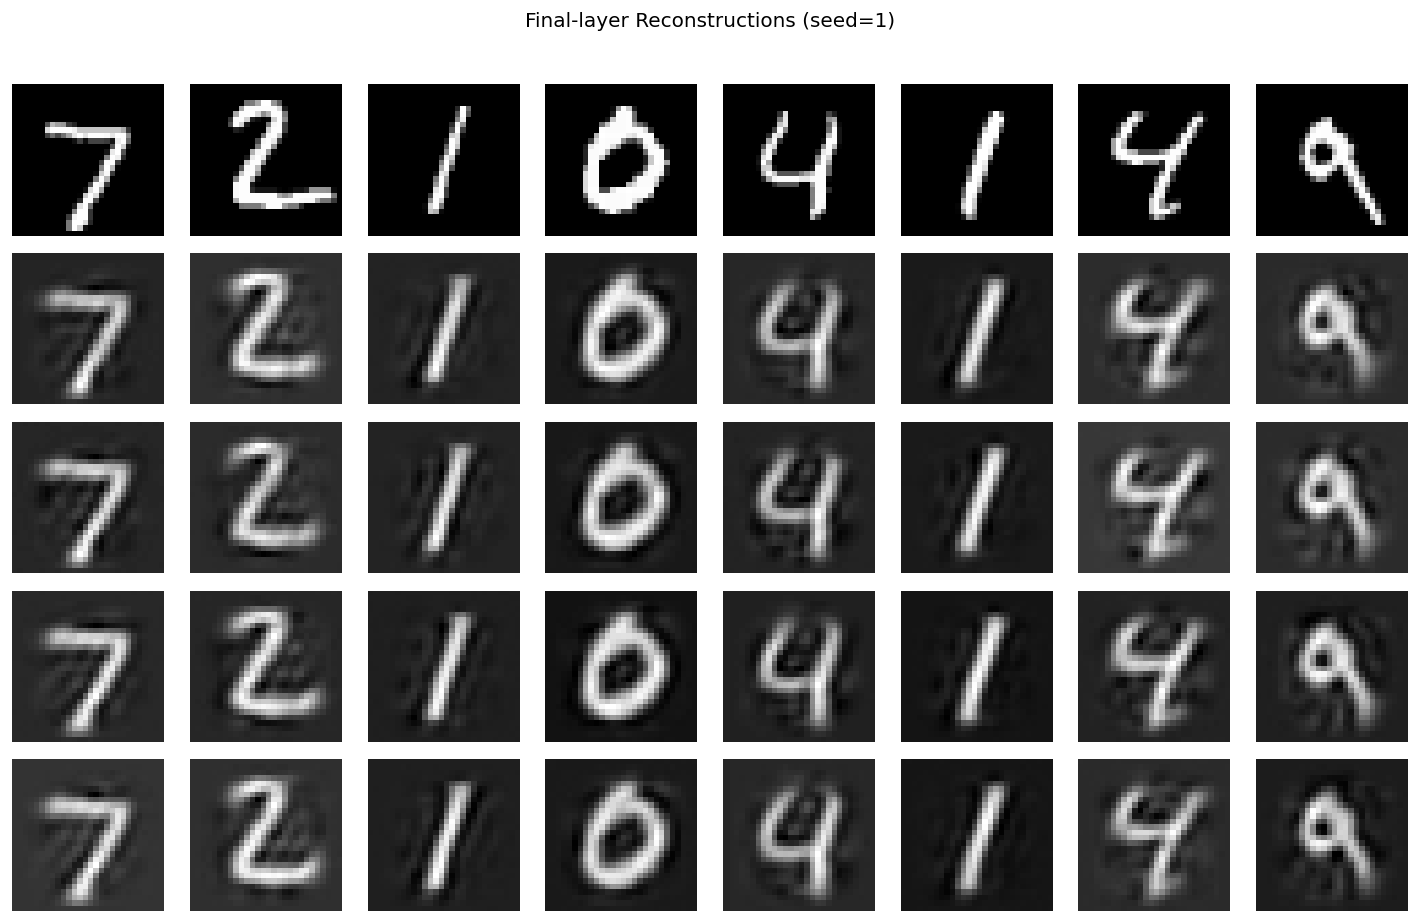

In [18]:
# ============================================================
# 7b. Reconstruction examples
# ============================================================
_, _, _, test_loader = make_dataset_loaders(DATASET, batch_size=8)
test_images, _ = next(iter(test_loader))
x = prepare_eval_batch(Config(device=DEVICE), test_images)
n_show = min(8, x.shape[0])

recon_by_mode = {}
for mode in MODES:
    steps = METHOD_STEPS[mode]
    cfg = Config(
        mode=mode,
        layer_dims=LAYER_DIMS,
        lambdas=LAMBDAS,
        betas=BETAS,
        infer_steps=steps["infer_steps"],
        lista_steps=steps["lista_steps"],
        batch_size=8,
        device=DEVICE,
    )
    Ds = results[mode]["Ds"]
    Ds_for_inf, lambdas, betas, etas = build_eval_inference_context(cfg, [d.detach() for d in Ds])
    codes = results[mode]["infer_module"](
        x=x,
        Ds_for_inference=Ds_for_inf,
        lambdas=lambdas,
        betas=betas,
        infer_steps=steps["infer_steps"],
        eta_scale=1.0,
        etas=etas,
    )
    eff_dicts = compute_effective_dictionaries([d.detach() for d in Ds])
    recon_by_mode[mode] = (codes[-1].detach().cpu() @ eff_dicts[-1].detach().cpu().t()).view(-1, H, W)

fig, axes = plt.subplots(1 + len(MODES), n_show, figsize=(1.5 * n_show, 1.5 * (1 + len(MODES))))

x_cpu = x.detach().cpu().view(-1, H, W)
for col in range(n_show):
    axes[0, col].imshow(x_cpu[col], cmap="gray")
    axes[0, col].axis("off")
    if col == 0:
        axes[0, col].set_ylabel("Input", rotation=0, labelpad=28, va="center")

for row_idx, mode in enumerate(MODES, start=1):
    x_rec = recon_by_mode[mode]
    for col in range(n_show):
        axes[row_idx, col].imshow(x_rec[col], cmap="gray")
        axes[row_idx, col].axis("off")
        if col == 0:
            axes[row_idx, col].set_ylabel(MODE_LABELS[mode], rotation=0, labelpad=28, va="center")

fig.suptitle(f"Final-layer Reconstructions (seed={SEED})", y=1.02)
plt.tight_layout()
plt.savefig(_DEMO_DIR / "demo_07_reconstructions.png", dpi=180, bbox_inches="tight")
plt.show()